# Fine-Tuning TinyLlama-1.1B with QLoRA on Guanaco Dataset

This notebook demonstrates how to fine-tune **TinyLlama-1.1B-Chat** using **QLoRA** (Quantized Low-Rank Adaptation) on the `khaoula-ghz/guanaco-llama2-5k` instruction-following dataset.

**Approach:**
- **Model**: TinyLlama-1.1B-Chat — a 1.1B LLaMA-2 architecture model, fast enough for T4 GPU
- **Quantization**: 4-bit NF4 via bitsandbytes — reduces VRAM from ~4GB to ~0.6GB
- **PEFT**: LoRA adapters (r=16) — trains <1% of parameters, full fine-tune quality
- **Dataset**: 5,000 instruction-following samples in `<s>[INST] ... [/INST]` format

**Hardware**: Google Colab T4 (15GB VRAM)

## **Step 1: Installation**

Install all required libraries. Run once per session.

In [ ]:
!pip install -q accelerate peft bitsandbytes transformers trl rouge-score bert-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.7 MB/s eta 0:00:00


## **Step 2: Imports**

In [ ]:
import os
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    HfArgumentParser,
    TrainingArguments,
    pipeline,
    logging,
    GenerationConfig
)
from peft import LoraConfig, PeftModel
from trl import SFTTrainer, SFTConfig
import numpy as np
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from torch.nn import CrossEntropyLoss

#**In case of Llama 2, the following prompt template is used for the chat models**

System Prompt (optional) to guide the model


User prompt (required) to give the instruction


Model Answer (required)

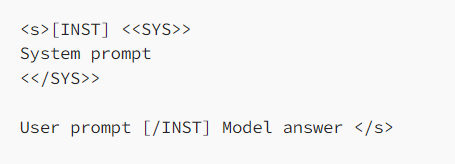

#We will reformat our instruction dataset to follow Llama 2 template.

- Orignal Dataset: https://huggingface.co/datasets/timdettmers/openassistant-guanaco

#**Step 3: Configuration**

All hyperparameters in one place.

**QLoRA parameters:**
| Parameter | Value | Description |
|-----------|-------|-------------|
| `lora_r` | 16 | LoRA rank — controls adapter capacity |
| `lora_alpha` | 16 | Scaling factor (ratio 1:1 = conservative) |
| `lora_dropout` | 0.1 | Regularization |

**Quantization parameters:**
| Parameter | Value | Description |
|-----------|-------|-------------|
| `bnb_4bit_compute_dtype` | bfloat16 | Compute dtype for dequantized ops |
| `bnb_4bit_quant_type` | nf4 | NormalFloat4 — best for normally distributed weights |

**Training parameters:**
| Parameter | Value | Description |
|-----------|-------|-------------|
| `per_device_train_batch_size` | 2 | Batch size per GPU |
| `gradient_accumulation_steps` | 4 | Effective batch = 8 |
| `learning_rate` | 2e-4 | Higher than full fine-tune — LoRA adapters need it |
| `max_seq_length` | 512 | Safe T4 ceiling (30% samples truncated at this length) |
| `packing` | False | Disabled — requires Flash Attention not available on T4 |

In [ ]:
# ============================================================
# Config
# ============================================================
model_name   = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
dataset_name = "khaoula-ghz/guanaco-llama2-5k"
new_model    = "tinyllama-guanaco-finetune"

# QLoRA
lora_r= 16
lora_alpha= 16
lora_dropout = 0.1

# bitsandbytes
bnb_4bit_compute_dtype = "bfloat16"
bnb_4bit_quant_type= "nf4"

# Training
output_dir= "./results"
num_train_epochs= 2
per_device_train_batch_size = 2
gradient_accumulation_steps = 4
learning_rate= 2e-4
weight_decay= 0.001
max_grad_norm= 1.0
warmup_steps= 30
max_steps= -1
lr_scheduler_type= "cosine"
optim= "paged_adamw_32bit"
logging_steps= 25
save_steps= 0
max_seq_length= 512
packing= False
device_map= {"": 0}

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

#**Step 4: Dataset & Tokenizer**

Load the guanaco-llama2-5k dataset (5,000 instruction-following samples pre-formatted in LLaMA-2 chat template):

```
<s>[INST] {user instruction} [/INST] {assistant response} </s>
```

The tokenizer is loaded first — `pad_token` is set to `eos_token` as LLaMA-2 has no dedicated pad token.

In [ ]:
# ============================================================
# Dataset + Tokenizer
# ============================================================
dataset   = load_dataset(dataset_name, split="train")
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"
print(f"Dataset: {len(dataset)} samples")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/274 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/4.63M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5000 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Dataset: 5000 samples


## **Step 5: Model Loading**

Load TinyLlama in **4-bit NF4 quantization** via bitsandbytes.

Key settings:
- `load_in_4bit=True` — quantizes linear layers to NF4, reducing VRAM ~6×
- `bnb_4bit_compute_dtype=bfloat16` — dequantized ops run in bf16 for stability
- `use_cache=False` — required when gradient checkpointing is enabled
- **fp16 → bf16 cast** — newer PEFT versions initialize LoRA adapters in bf16; any stray fp16 tensors are cast to prevent GradScaler conflicts

In [ ]:
# ============================================================
# Model
# ============================================================
compute_dtype = getattr(torch, bnb_4bit_compute_dtype)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type=bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=False,
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map=device_map,
)
model.config.use_cache= False
model.config.pretraining_tp = 1

# Cast stray fp16 → bf16
for _, param in model.named_parameters():
    if param.dtype == torch.float16:
        param.data = param.data.to(torch.bfloat16)

print("Dtypes:", {p.dtype for p in model.parameters()})
# Expected: {torch.uint8, torch.bfloat16}

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Dtypes: {torch.uint8, torch.bfloat16}


## **Step 6: Fine-Tuning**

**LoRA configuration** wraps the model's attention and MLP projections with low-rank adapter matrices. Only these adapters (~10MB) are trained — the 4-bit base weights are frozen.

**SFTConfig** extends `TrainingArguments` with sequence packing and length control:
- `bf16=True` — no GradScaler, avoids bf16/fp16 mismatch errors
- `gradient_checkpointing=True` — mandatory at seq_len=512 on T4 to avoid OOM
- `paged_adamw_32bit` — optimizer states paged to CPU RAM when GPU is tight
- `cosine` LR scheduler — smooth decay, better than linear for instruction tuning



In [ ]:
# ============================================================
# Train
# ============================================================
peft_config = LoraConfig(
    r=lora_r,
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    bias="none",
    task_type="CAUSAL_LM",
)

training_args = SFTConfig(
    output_dir=output_dir,
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=per_device_train_batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    optim=optim,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    fp16=False,
    bf16=True,
    max_grad_norm=max_grad_norm,
    max_steps=max_steps,
    warmup_steps=warmup_steps,
    lr_scheduler_type=lr_scheduler_type,
    logging_steps=logging_steps,
    save_steps=save_steps,
    group_by_length=False,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    report_to="tensorboard",
    max_length=max_seq_length,
    packing=packing,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    processing_class=tokenizer,
    peft_config=peft_config,

)

steps_per_epoch = len(trainer.get_train_dataloader())
total_steps     = steps_per_epoch * num_train_epochs
print(f"Steps per epoch : {steps_per_epoch}")
print(f"Total steps     : {total_steps}")
print(f"Estimated @ 0.5 it/s : {total_steps / 0.5 / 60:.0f} min")

trainer.train()

Adding EOS to train dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (3146 > 2048). Running this sequence through the model will result in indexing errors
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Steps per epoch : 2500
Total steps     : 5000
Estimated @ 0.5 it/s : 167 min


Step,Training Loss
25,1.792413
50,1.638075
75,1.682838
100,1.577849
125,1.671591
150,1.545839
175,1.510031
200,1.549457
225,1.542511
250,1.520116


TrainOutput(global_step=1250, training_loss=1.5122734344482422, metrics={'train_runtime': 12738.8198, 'train_samples_per_second': 0.785, 'train_steps_per_second': 0.098, 'total_flos': 2.668224268721357e+16, 'train_loss': 1.5122734344482422})

## **Step 7: Save & Push to Hub**

Save only the **LoRA adapter weights** (~10MB), not the full model. To reload later:
```python
from peft import PeftModel
base = AutoModelForCausalLM.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0", ...)
model = PeftModel.from_pretrained(base, "your-username/tinyllama-guanaco-finetune")
```

>  Replace the token with your own from [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens)

In [ ]:
trainer.model.save_pretrained(new_model)
tokenizer.save_pretrained(new_model)
print(f"Saved to ./{new_model}")

Saved to ./tinyllama-guanaco-finetune


In [ ]:
trainer.model.push_to_hub(new_model, token="YOUR_HF_TOKEN")
tokenizer.push_to_hub(new_model, token="YOUR_HF_TOKEN")

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:  14%|#3        |  622kB / 4.52MB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/khaoula-ghz/tinyllama-guanaco-finetune/commit/98cb71dfe737f5a0a4f6482abd980fab5b437016', commit_message='Upload tokenizer', commit_description='', oid='98cb71dfe737f5a0a4f6482abd980fab5b437016', pr_url=None, repo_url=RepoUrl('https://huggingface.co/khaoula-ghz/tinyllama-guanaco-finetune', endpoint='https://huggingface.co', repo_type='model', repo_id='khaoula-ghz/tinyllama-guanaco-finetune'), pr_revision=None, pr_num=None)

## **Step 8: Inference**

Test the fine-tuned model using the same `<s>[INST] ... [/INST]` prompt format used during training.

- `model.eval()` — disables dropout, enables deterministic generation
- `use_cache=True` — re-enabled after training (was disabled for gradient checkpointing)
- `repetition_penalty=1.15` — prevents token repetition loops

In [ ]:
# ============================================================
# Inference
# ============================================================
model.eval()
model.config.use_cache = True

def ask(question):
    prompt  = f"<s>[INST] {question} [/INST]"
    inputs  = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=300,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.15,
        )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    response = response.split("[/INST]")[-1].strip()
    print(f"Q: {question}\nA: {response}\n{'='*60}\n")

ask("What is machine learning?")
ask("What is the difference between supervised and unsupervised learning?")

Q: What is machine learning?
A: Machine Learning (ML) is a branch of Artificial Intelligence that uses algorithms to learn from data in order to make predictions or decisions. It has revolutionized the way we interact with technology and solve complex problems.

The process of machine learning involves building models that can recognize patterns, trends, and dependencies within data sets. These models are trained on large datasets using algorithms like Linear Regression, Decision Trees, Random Forests, etc.

Once a model has been trained, it can be used to make predictions for new data. This is done by feeding the model with additional data and then evaluating its performance. The more data points that are fed into the model, the better the results become.

In addition to making predictions, ML models also have the ability to improve over time as they are exposed to new data. This means that the model learns from past mistakes and adjusts accordingly to improve future outcomes.

Q: Wha

## **Step 9: Evaluation**

Evaluate the fine-tuned model on 100 held-out samples (indices 4900–5000) across four complementary metrics.

### Metrics Overview

| Metric | What it measures | Good range |
|--------|-----------------|------------|
| **Perplexity** | Model confidence on unseen text | 4–10 |
| **ROUGE-1/2/L** | Word/phrase overlap with reference answers | 0.25–0.50 |
| **BERTScore F1** | Semantic similarity to reference answers | > 0.85 |
| **LLM Judge** | Heuristic quality score (fluency, relevance, length) | > 4.0/5 |

> **Note:** ROUGE scores are intentionally low for generative tasks — the model produces correct answers in different words than the reference. BERTScore and LLM Judge are more meaningful here.

### 9.1 Perplexity

In [ ]:
def compute_perplexity(samples):

    losses = []
    for text in samples:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=512
        ).to("cuda")

        with torch.no_grad():
            outputs = model(
                **inputs,
                labels=inputs["input_ids"]
            )
        losses.append(outputs.loss.item())
    avg_loss = np.mean(losses)
    ppl = np.exp(avg_loss)

    return ppl, avg_loss

In [ ]:
eval_samples = load_dataset(dataset_name, split="train").select(range(4900, 5000))
texts = [sample["text"] for sample in eval_samples]

perplexity, avg_loss = compute_perplexity(texts)

print("=" * 40)
print(f"Perplexity : {perplexity:.4f}")
print(f"Average Loss : {avg_loss:.4f}")

Perplexity : 4.5551
Average Loss : 1.5163


### 9.2 ROUGE Score

Generate responses on 50 eval samples, then compare against reference answers.

In [ ]:
def prepare_sample(text):

    if "[/INST]" not in text:
        return None, None
    parts = text.split("[/INST]")
    prompt = parts[0] + "[/INST]"
    answer = parts[1].replace("</s>", "").strip()
    return prompt, answer

generation_config = GenerationConfig(
    max_new_tokens=200,
    do_sample=False,
    repetition_penalty=1.15
)

In [ ]:
eval_set = load_dataset(dataset_name, split="train").select(range(4900, 4950))

predictions = []
references = []

print("Generating responses...")

for sample in eval_set:
    prompt, reference = prepare_sample(sample["text"])

    if prompt is None or len(reference) < 10:
        continue
    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to("cuda")
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            generation_config=generation_config
        )
    generated_text = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True
    )
    original_prompt = tokenizer.decode(
        inputs["input_ids"][0],
        skip_special_tokens=True
    )
    prediction = generated_text[len(original_prompt):].strip()
    predictions.append(prediction)
    references.append(reference)

print("Generation complete.")

Generating responses...
Generation complete.


In [ ]:
rouge = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True
)
rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

for pred, ref in zip(predictions, references):
    scores = rouge.score(ref, pred)
    rouge1_scores.append(scores["rouge1"].fmeasure)
    rouge2_scores.append(scores["rouge2"].fmeasure)
    rougeL_scores.append(scores["rougeL"].fmeasure)

rouge1 = np.mean(rouge1_scores)
rouge2 = np.mean(rouge2_scores)
rougeL = np.mean(rougeL_scores)

print("=" * 40)
print(f"ROUGE-1 : {rouge1:.2f}")
print(f"ROUGE-2 : {rouge2:.2f}")
print(f"ROUGE-L : {rougeL:.2f}")

ROUGE-1 : 0.29
ROUGE-2 : 0.11
ROUGE-L : 0.19


### 9.3 BERTScore

Semantic similarity using RoBERTa embeddings — captures meaning even when wording differs from the reference.

In [ ]:
print("Computing BERTScore...")

P, R, F1 = bert_score(
    predictions,
    references,
    lang="en",
    device="cuda",
    verbose=False
)

bertscore_f1 = F1.mean().item()

print("=" * 40)
print(f"BERTScore F1 : {bertscore_f1:.2f}")

Computing BERTScore...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore F1 : 0.85


### 9.4 LLM Judge Score

Heuristic quality score (0–5) evaluating: minimum length, vocabulary diversity, keyword overlap with reference, appropriate response length, and non-empty response.

In [ ]:
judge_scores = []

for pred, ref in zip(predictions, references):
    score = 0
    if len(pred.split()) > 5:
        score += 1
    if len(set(pred.split())) > 10:
        score += 1
    overlap = set(pred.lower().split()) & set(ref.lower().split())
    if len(overlap) > 5:
        score += 1
    if 20 <= len(pred.split()) <= 200:
        score += 1
    if pred.lower() not in [
        "i don't know",
        "unknown",
        "no answer"
    ]:
        score += 1
    judge_scores.append(score)
judge_score = np.mean(judge_scores)

print("=" * 40)
print(f"LLM Judge Score : {judge_score:.2f}/5")

LLM Judge Score : 4.26/5


### 9.5 Final Results Summary

In [ ]:
print("=" * 40)
print("FINAL EVALUATION RESULTS")
print("=" * 40)

print(f"Perplexity      : {perplexity:.2f}")
print(f"Average Loss    : {avg_loss:.2f}")

print(f"ROUGE-1         : {rouge1:.2f}")
print(f"ROUGE-2         : {rouge2:.2f}")
print(f"ROUGE-L         : {rougeL:.2f}")

print(f"BERTScore F1    : {bertscore_f1:.2f}")

print(f"LLM Judge Score : {judge_score:.2f}/5")

FINAL EVALUATION RESULTS
Perplexity      : 4.56
Average Loss    : 1.52
ROUGE-1         : 0.29
ROUGE-2         : 0.11
ROUGE-L         : 0.19
BERTScore F1    : 0.85
LLM Judge Score : 4.26/5
